In [1]:
import pandas as pd
from google.colab import drive
pd.set_option('display.max_columns', None)

In [2]:
drive.mount('/content/drive')
df_cleaned = pd.read_csv('/content/drive/My Drive/Medical_Insurance_Prediction_Project/medical_insurance_cleaned_engineered.csv')

Mounted at /content/drive


In [3]:
df_cleaned

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,annual_medical_cost,annual_premium,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,had_major_procedure,bp_category,bmi_group,ldl_group,hba1c_group,annual_medical_cost_grouped
0,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,Never,2,0,0,4,121.0,76.0,123.8,5.28,Preferred Provider Organization,Bronze,1000,20,4,6938.06,876.05,0,0,0,0,0,0,0,0,1,0,0,Elevated,Overweight,Near Optimal,Normal,Low
1,79,Female,North,Urban,12800.0,High School Dropout,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,Point-of-Service,Gold,1000,10,1,1632.61,445.10,0,0,0,0,0,0,0,0,1,1,0,Hypertension Stage 1,Overweight,Optimal,Normal,Very Low
2,68,Male,North,Rural,40700.0,High School,Married,Retired,5,3,31.5,Never,Never,1,0,0,4,160.0,84.0,129.5,5.51,Health Maintenance Organization,Platinum,500,20,10,7661.01,1538.02,1,0,0,0,0,1,0,0,0,1,0,Hypertension Stage 1,Obese I,Near Optimal,Normal,Low
3,15,Male,North,Suburban,15600.0,College,Married,Self-employed,5,3,31.6,Never,Never,0,0,0,1,104.0,68.0,160.3,8.50,Health Maintenance Organization,Silver,500,20,5,5130.27,820.63,0,1,0,0,0,0,0,0,0,0,0,Normal,Obese I,High,Diabetes,Low
4,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,3,0,0,2,136.0,83.0,171.0,5.20,Point-of-Service,Platinum,500,10,7,1700.73,500.93,1,0,0,0,0,0,0,0,1,0,0,Hypertension Stage 1,Obese I,High,Normal,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,50,Male,West,Urban,127200.0,High School Dropout,Married,Employed,2,0,28.2,Never,Occasional,0,0,0,1,115.0,74.0,102.5,4.98,Preferred Provider Organization,Bronze,500,10,10,1295.04,329.32,0,0,0,0,0,0,0,0,0,0,0,Normal,Overweight,Near Optimal,Normal,Very Low
99996,42,Male,East,Suburban,21600.0,High School,Married,Employed,2,0,27.6,Never,Occasional,0,0,0,1,101.0,66.0,177.1,5.66,Preferred Provider Organization,Silver,5000,20,4,1451.73,424.21,0,0,0,0,0,0,0,0,0,0,0,Normal,Overweight,High,Normal,Very Low
99997,41,Male,West,Rural,81900.0,High School,Divorced,Unemployed,1,0,29.8,Former,Weekly,7,0,0,1,128.0,83.0,118.8,5.52,Preferred Provider Organization,Gold,500,30,9,2291.00,534.90,1,0,0,0,0,0,0,0,0,0,0,Hypertension Stage 1,Overweight,Near Optimal,Normal,Low
99998,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,2,21.9,Never,Occasional,4,0,0,2,110.0,73.0,134.9,5.25,Point-of-Service,Bronze,2000,20,3,1279.76,342.86,0,0,0,0,0,0,0,0,0,1,0,Normal,Normal,Borderline High,Normal,Very Low


In [4]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   sex                          100000 non-null  object 
 2   region                       100000 non-null  object 
 3   urban_rural                  100000 non-null  object 
 4   income                       100000 non-null  float64
 5   education                    100000 non-null  object 
 6   marital_status               100000 non-null  object 
 7   employment_status            100000 non-null  object 
 8   household_size               100000 non-null  int64  
 9   dependents                   100000 non-null  int64  
 10  bmi                          100000 non-null  float64
 11  smoker                       100000 non-null  object 
 12  alcohol_freq                 100000 non-null  object 
 13  

In [5]:
import numpy as np

# Define age bins
age_bins = [0, 18, 30, 45, 60, 75, 100]
age_labels = ['0-18', '19-30', '31-45', '46-60', '61-75', '76-100']
df_cleaned['age_group'] = pd.cut(df_cleaned['age'], bins=age_bins, labels=age_labels, right=False)
age_group_counts = df_cleaned['age_group'].value_counts().sort_index()

# Define bin edges and labels for 'income'
income_bins = [0, 25000, 50000, 75000, 100000, 125000, 150000, float('inf')]
income_labels = ['<25k', '25k-50k', '50k-75k', '75k-100k', '100k-125k', '125k-150k', '>150k']
df_cleaned['income_group'] = pd.cut(df_cleaned['income'], bins=income_bins, labels=income_labels, right=False)

# Define bin edges and labels for 'bmi'
bmi_bins = [0, 18.5, 25, 30, 35, 40, float('inf')]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese I', 'Obese II', 'Obese III']
df_cleaned['bmi_group'] = pd.cut(df_cleaned['bmi'], bins=bmi_bins, labels=bmi_labels, right=False)

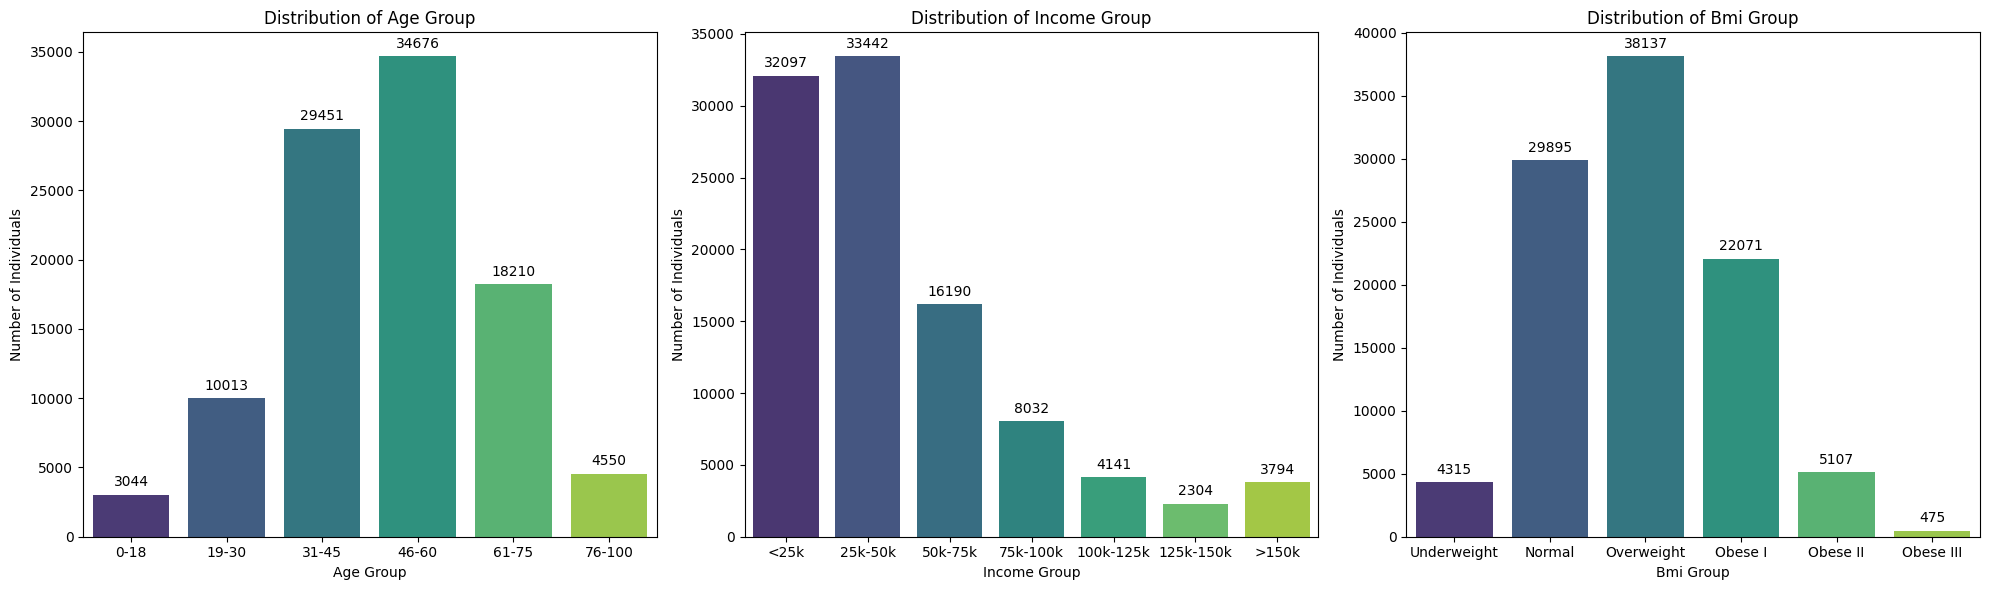

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns to be visualized
category_cols = ['age_group', 'income_group', 'bmi_group']

# Create a figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes = axes.flatten() # Flatten for easy iteration

# Iterate through each category column and plot its distribution
for i, col in enumerate(category_cols):
    counts = df_cleaned[col].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette='viridis', hue=counts.index, legend=False)
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Number of Individuals')

    # Rotate x-axis labels if they are too long, adjust for readability
    if col in ['income_group', 'bmi_group']:
        axes[i].tick_params(axis='x', rotation=0)

    # Add values on top of the bars
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.0f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center',
                         xytext=(0, 9),
                         textcoords='offset points')

plt.tight_layout()
plt.show()

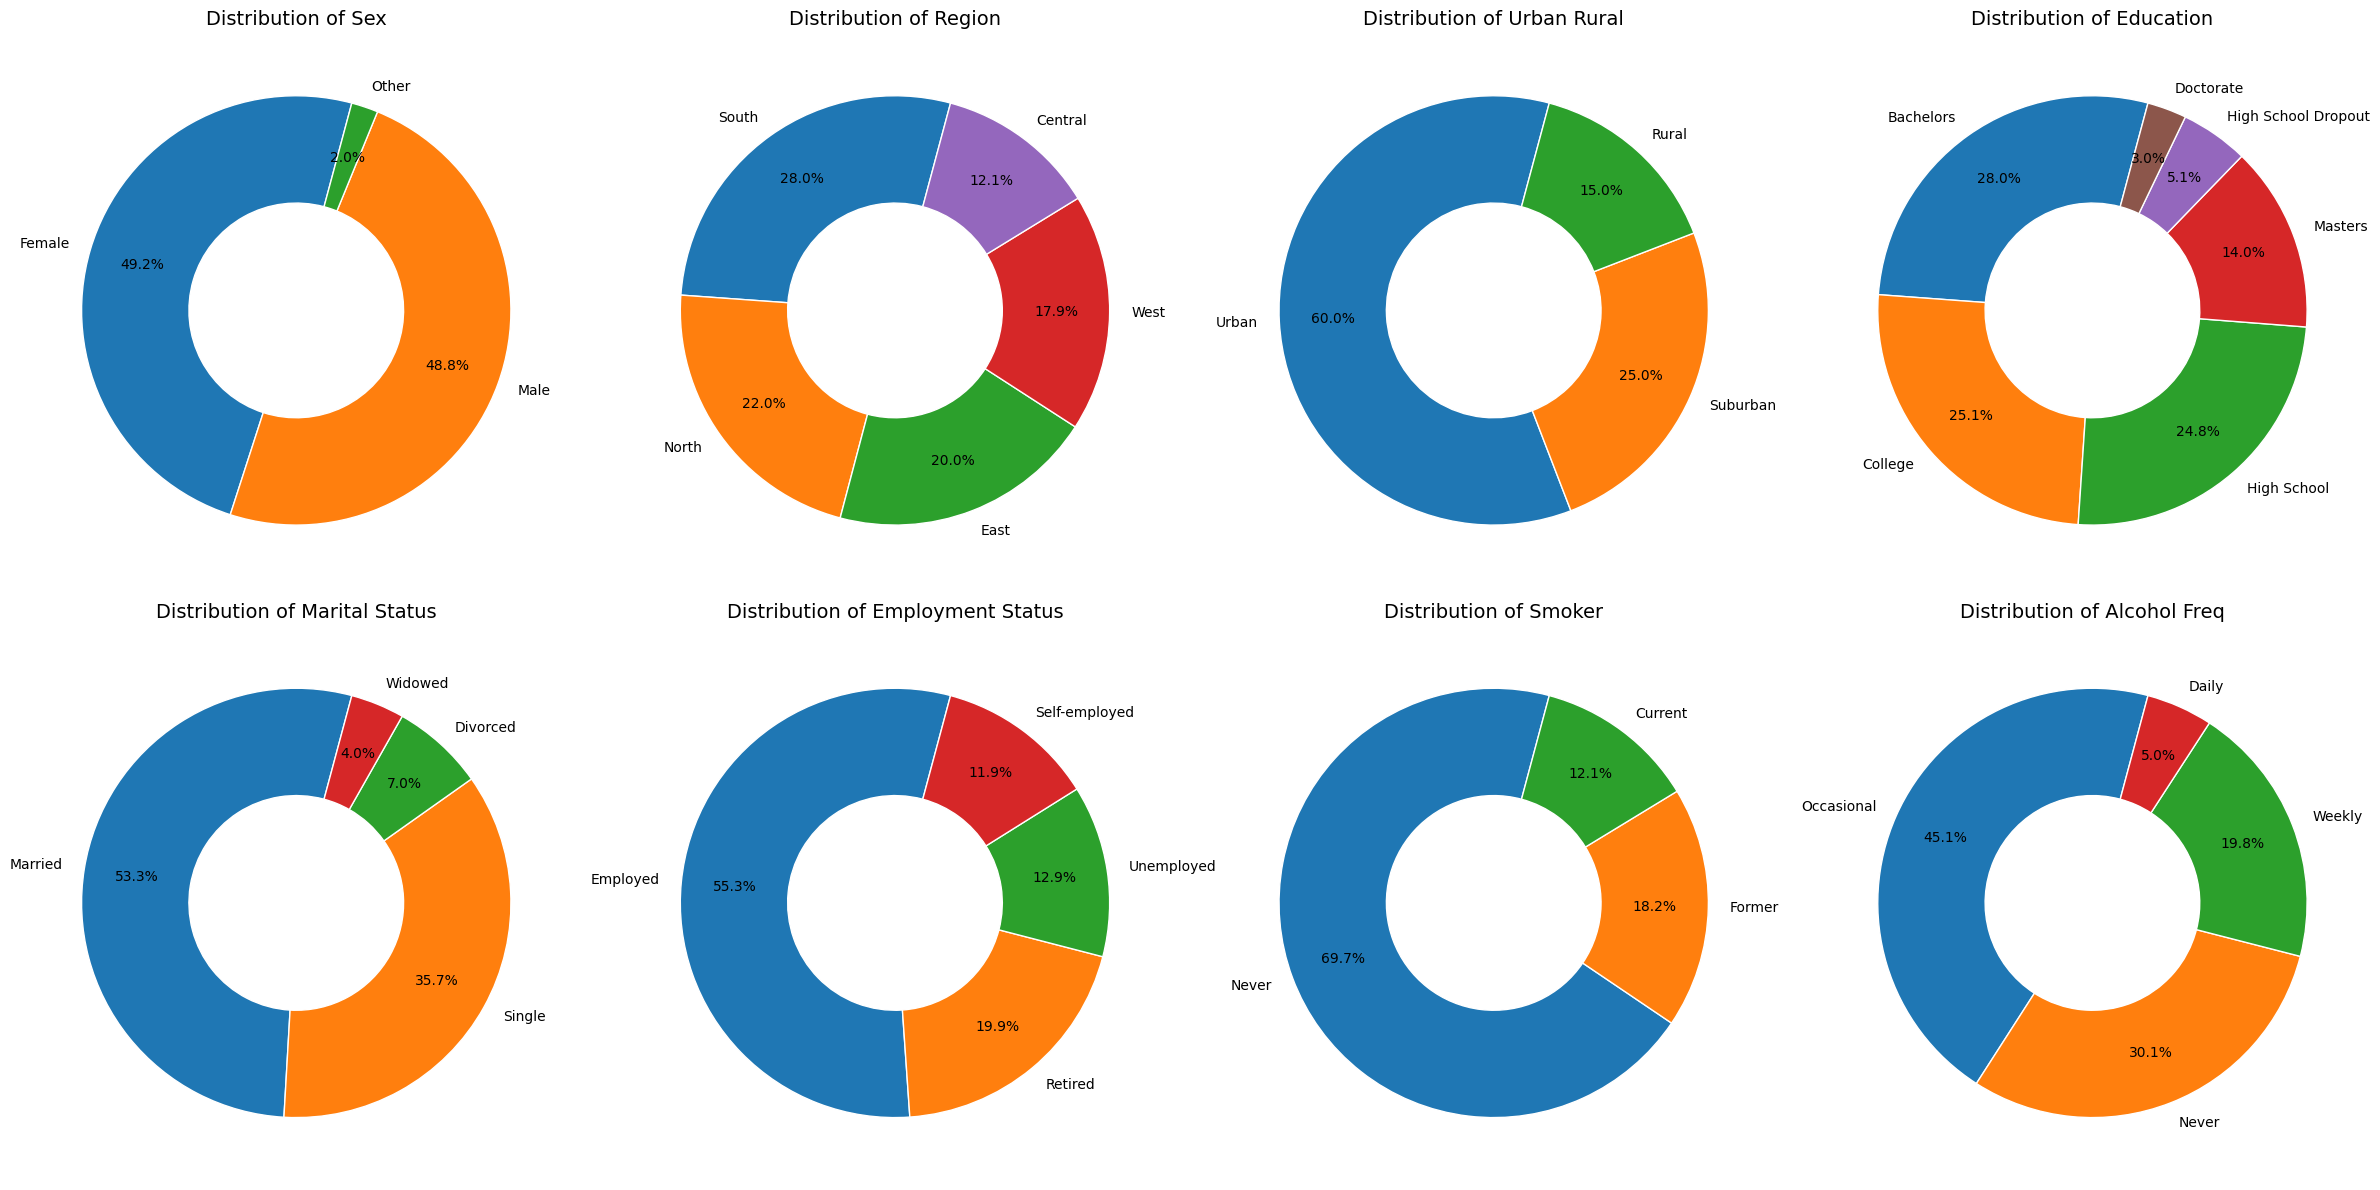

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the list of categorical columns
categorical_cols = ['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq']

# Create a figure and an 8-subplot grid (2 rows, 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Iterate through the columns and create donut charts
for i, col in enumerate(categorical_cols):
    # Calculate value counts and percentages
    counts = df_cleaned[col].value_counts()
    percentages = counts / len(df_cleaned) * 100

    # Create a pie chart
    wedges, texts, autotexts = axes[i].pie(percentages,
                                           labels=counts.index,
                                           autopct='%1.1f%%',
                                           startangle=75,
                                           pctdistance=0.75,
                                           wedgeprops=dict(width=0.5, edgecolor='w'))

    # Add a white circle in the center to create the donut effect
    centre_circle = plt.Circle((0,0),0.5,fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    # Set title
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=14)
    axes[i].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

    # Adjust font size of percentages
    for autotext in autotexts:
        autotext.set_fontsize(10)
    for text in texts:
        text.set_fontsize(10)


# Adjust layout and display the plot
plt.tight_layout()
plt.show()

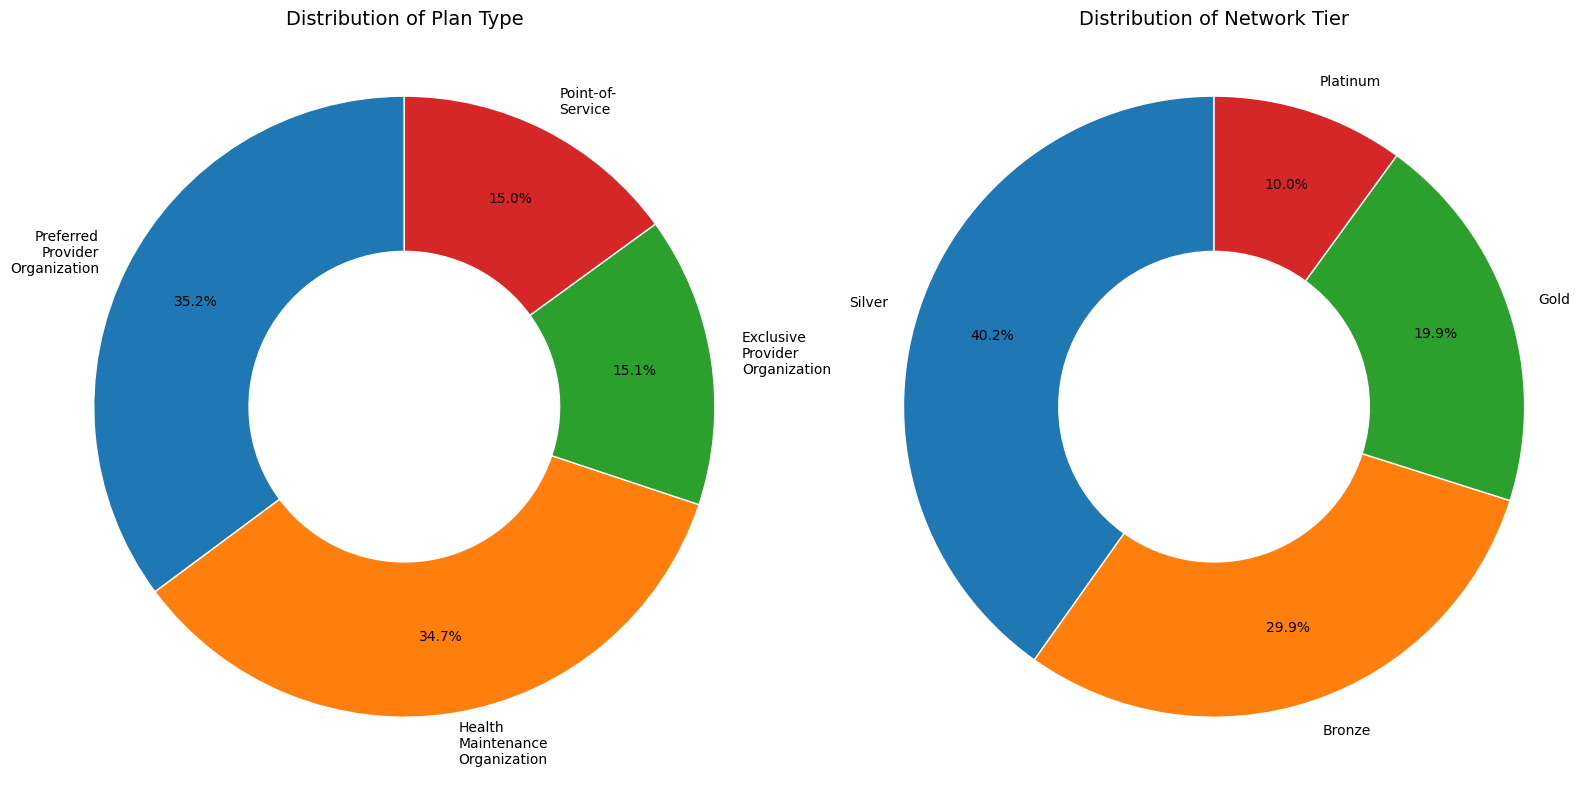

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# Define the list of columns for which to create donut charts
plan_network_cols = ['plan_type', 'network_tier']

# Create a figure and two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Iterate through the columns and create donut charts
for i, col in enumerate(plan_network_cols):
    # Calculate value counts and percentages
    counts = df_cleaned[col].value_counts()
    percentages = counts / len(df_cleaned) * 100

    # Wrap labels if they are too long
    wrapped_labels = [textwrap.fill(label, 15) for label in counts.index]

    # Create a pie chart
    wedges, texts, autotexts = axes[i].pie(percentages,
                                           labels=wrapped_labels,
                                           autopct='%1.1f%%',
                                           startangle=90,
                                           pctdistance=0.75,
                                           wedgeprops=dict(width=0.5, edgecolor='w'))

    # Add a white circle in the center to create the donut effect
    centre_circle = plt.Circle((0,0),0.4,fc='white')
    axes[i].add_artist(centre_circle)

    # Set title
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=14)
    axes[i].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

    # Adjust font size of percentages and labels
    for autotext in autotexts:
        autotext.set_fontsize(10)
    for text in texts:
        text.set_fontsize(10)


# Adjust layout and display the plot
plt.tight_layout()
plt.show()

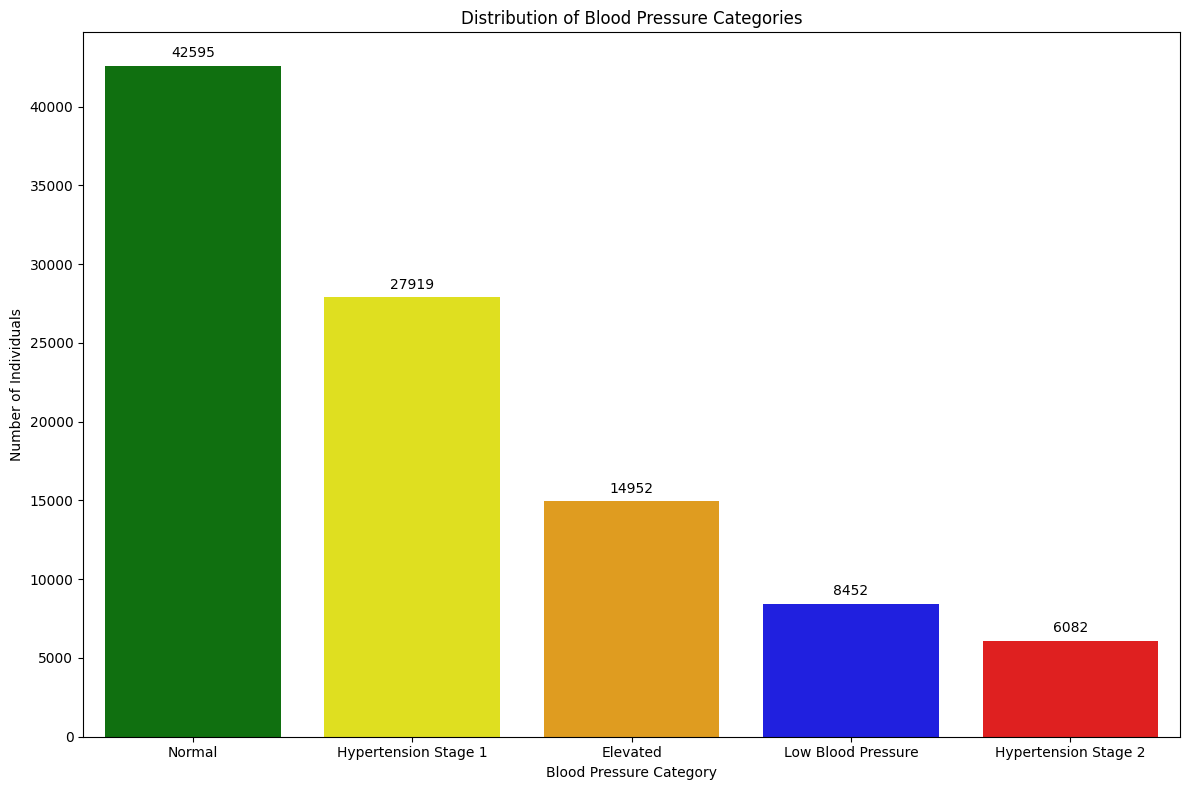

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each blood pressure category
bp_category_counts = df_cleaned['bp_category'].value_counts().reset_index()
bp_category_counts.columns = ['BP Category', 'Count']

# Define a custom color palette
custom_palette = {'Normal': 'green', 'Low Blood Pressure': 'blue', 'Elevated': 'orange', 'Hypertension Stage 1': 'yellow', 'Hypertension Stage 2': 'red'}

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='BP Category', y='Count', data=bp_category_counts, palette=custom_palette, hue='BP Category', legend=False)
plt.title('Distribution of Blood Pressure Categories')
plt.xlabel('Blood Pressure Category')
plt.ylabel('Number of Individuals')

# Wrap x-tick labels
for label in ax.get_xticklabels():
    label.set_wrap(True)
    label.set_horizontalalignment('center') # Center align wrapped text

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

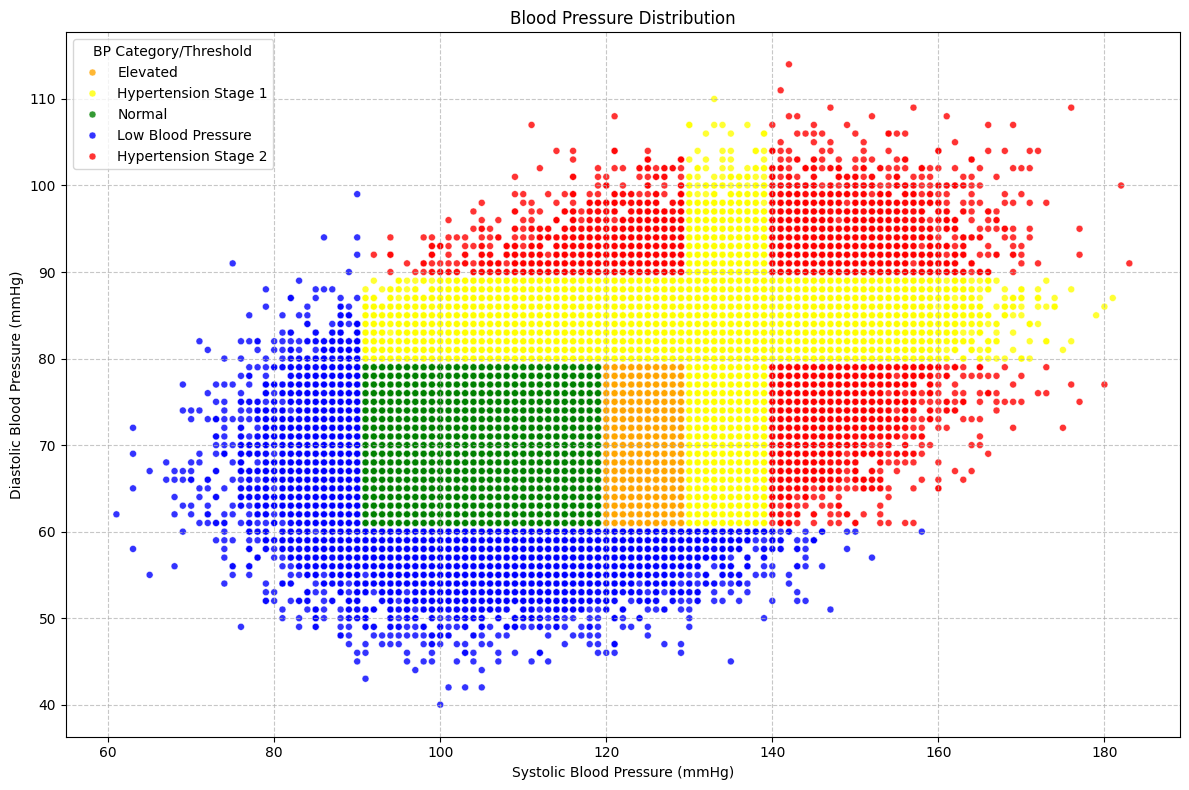

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(x='systolic_bp', y='diastolic_bp', hue='bp_category', data=df_cleaned,  palette={'Normal': 'green', 'Low Blood Pressure': 'blue', 'Elevated': 'orange', 'Hypertension Stage 1': 'yellow', 'Hypertension Stage 2': 'red'}, s=25, alpha=0.8)

plt.title('Blood Pressure Distribution')
plt.xlabel('Systolic Blood Pressure (mmHg)')
plt.ylabel('Diastolic Blood Pressure (mmHg)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='BP Category/Threshold')
plt.tight_layout()
plt.show()

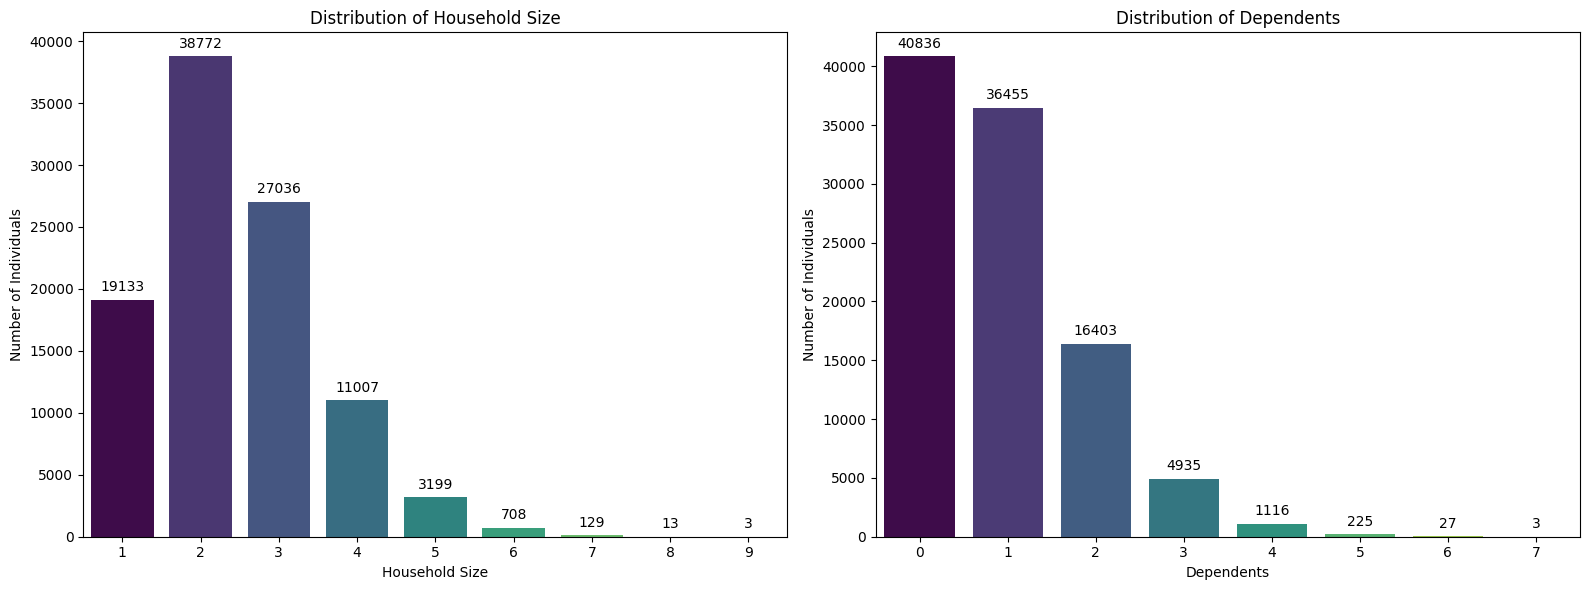

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns for which to create bar charts
size_dependents_cols = ['household_size', 'dependents']

# Create a figure and subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes = axes.flatten() # Flatten for easy iteration

# Iterate through each column and plot its distribution
for i, col in enumerate(size_dependents_cols):
    counts = df_cleaned[col].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette='viridis', hue=counts.index, legend=False)
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Number of Individuals')
    axes[i].tick_params(axis='x', rotation=0)

    # Add values on top of the bars
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.0f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center',
                         xytext=(0, 9),
                         textcoords='offset points')

plt.tight_layout()
plt.show()

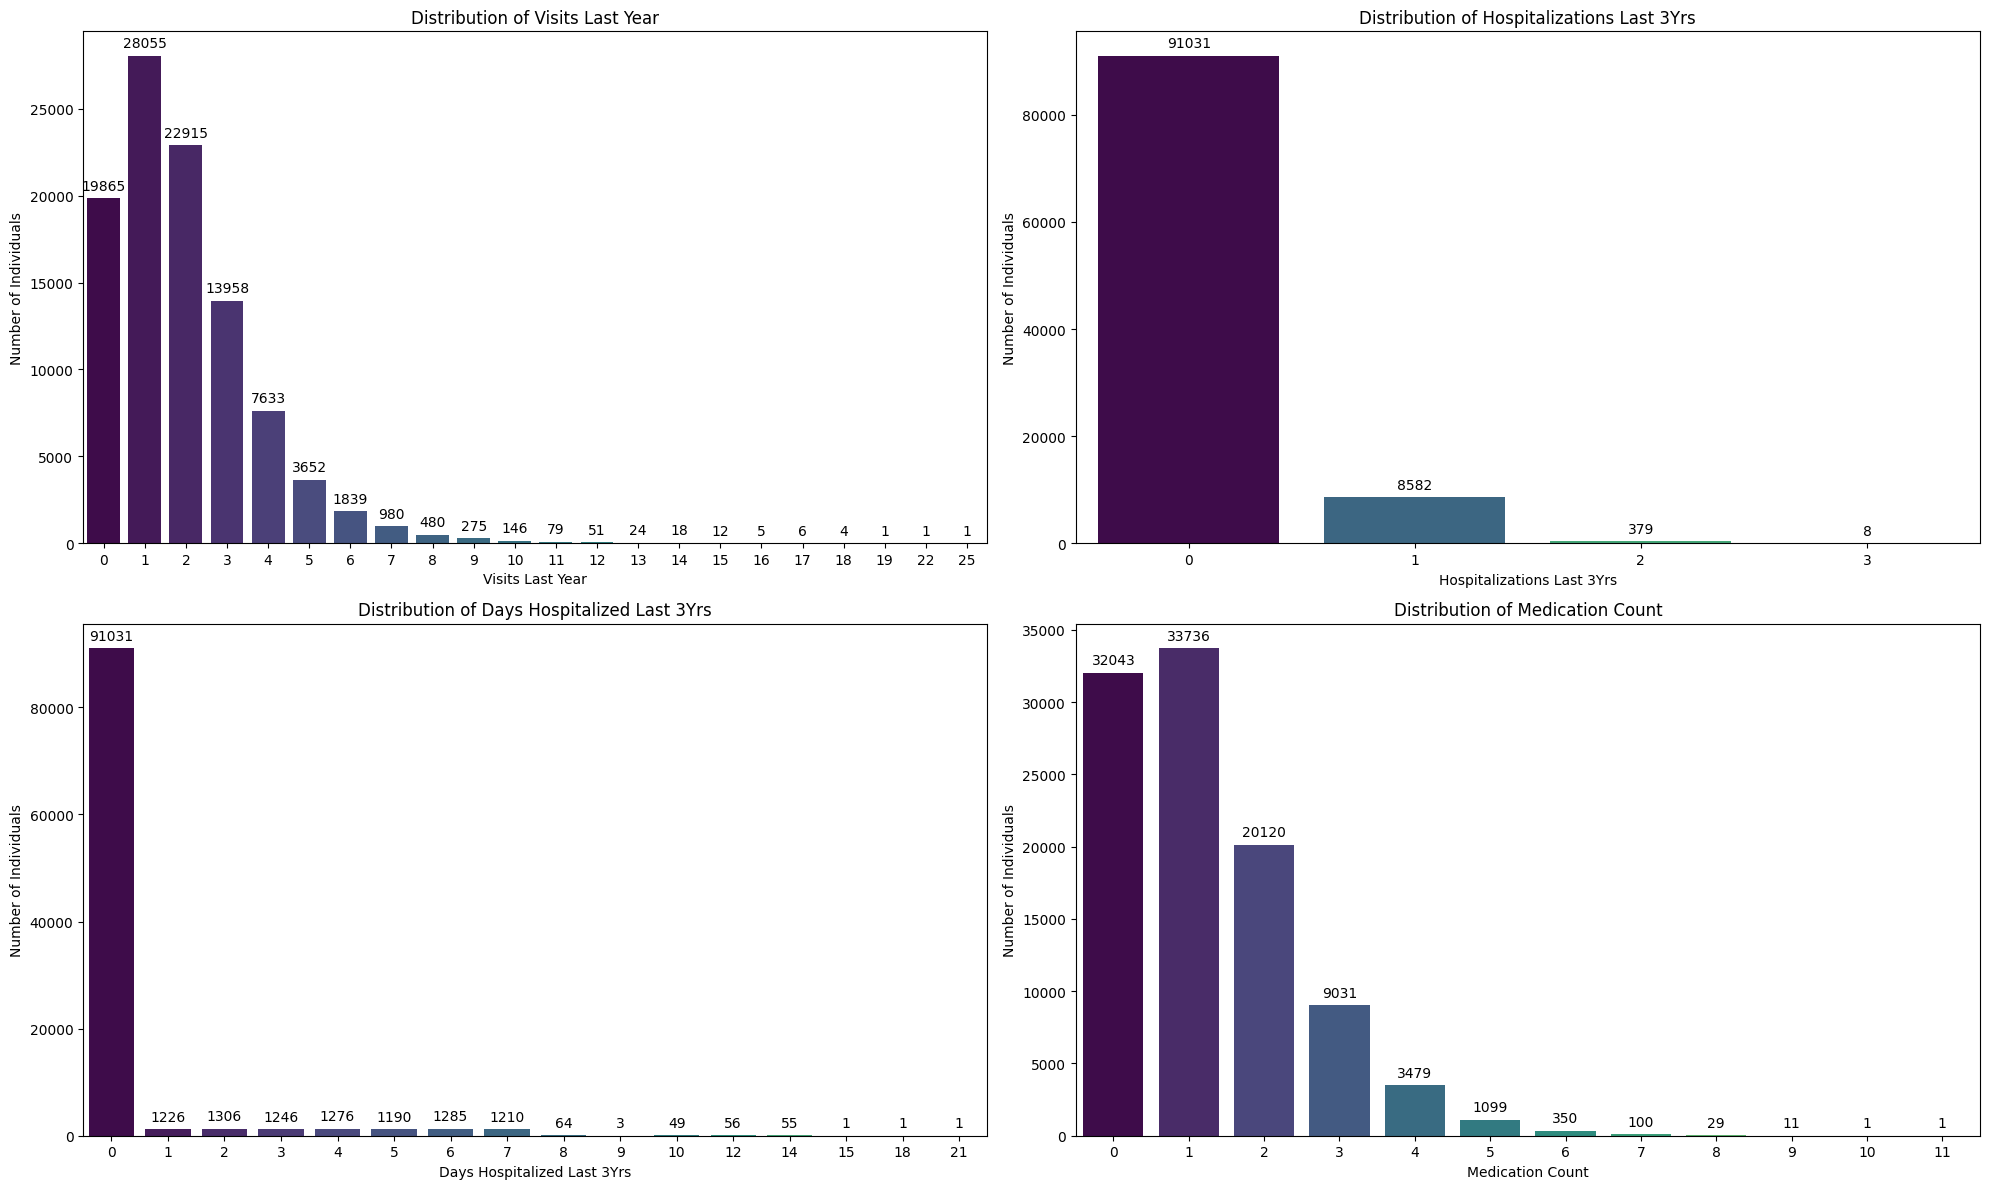

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns for which to create bar charts
medical_cols = ['visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count']

# Create a figure and subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten() # Flatten for easy iteration

# Iterate through each column and plot its distribution
for i, col in enumerate(medical_cols):
    counts = df_cleaned[col].value_counts().sort_index()
    ax = sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette='viridis', hue=counts.index, legend=False)
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Number of Individuals')
    axes[i].tick_params(axis='x', rotation=0)

    # Add values on top of the bars
    for p in ax.patches:
        axes[i].annotate(f'{p.get_height():.0f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

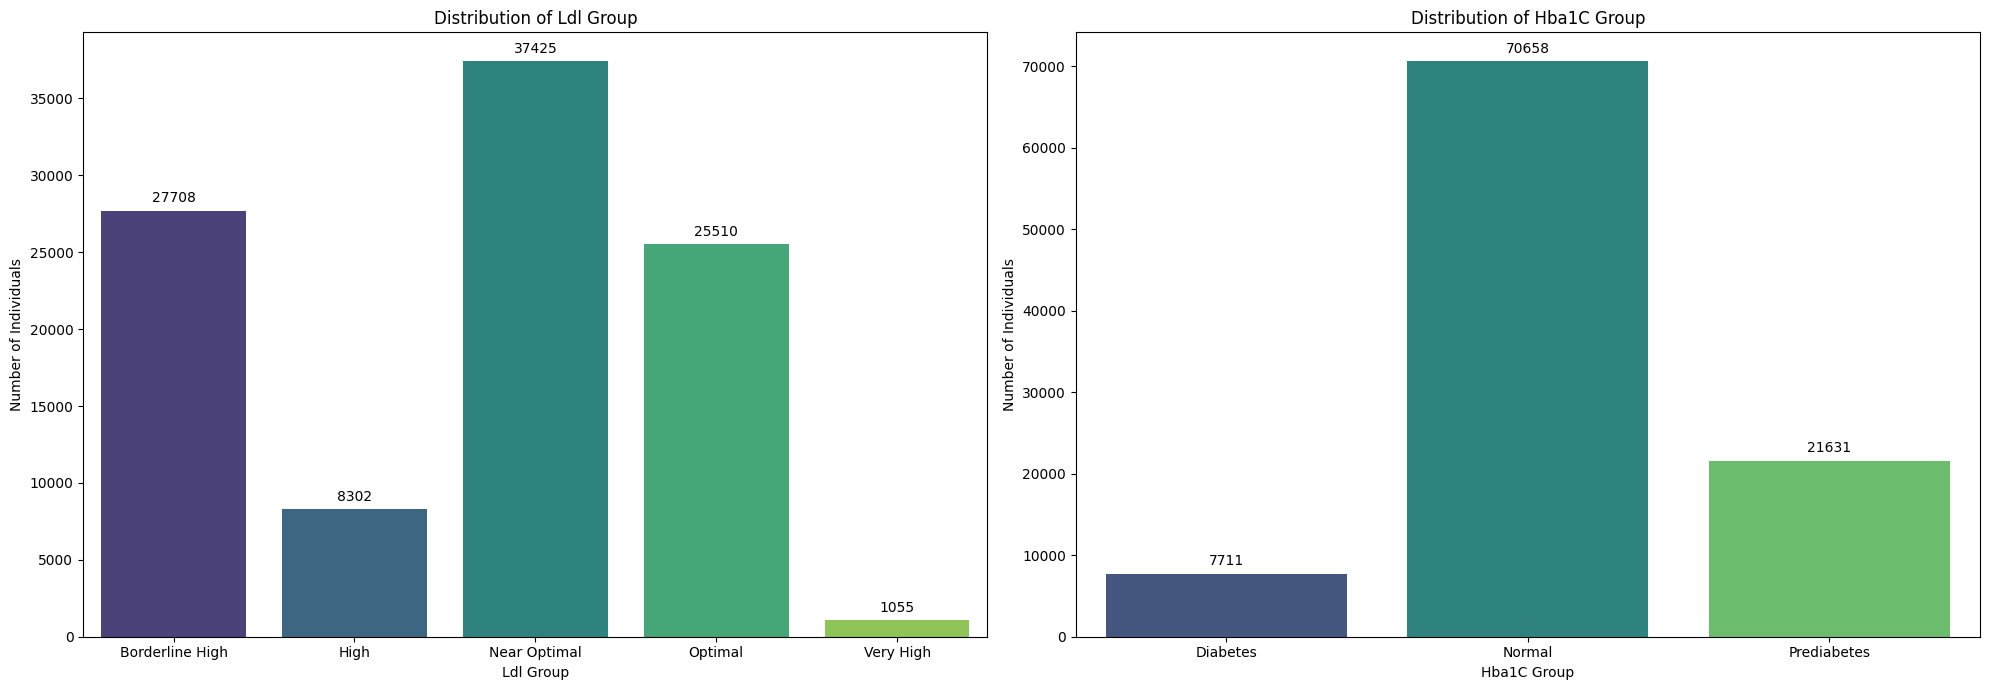

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns to be visualized
health_condition_cols = ['ldl_group', 'hba1c_group']

# Create a figure and subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
axes = axes.flatten() # Flatten for easy iteration

# Iterate through each category column and plot its distribution
for i, col in enumerate(health_condition_cols):
    counts = df_cleaned[col].value_counts().sort_index()
    ax = sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette='viridis', hue=counts.index, legend=False)
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Number of Individuals')

    # Wrap x-tick labels without adjusting font size
    for label in ax.get_xticklabels():
        label.set_wrap(True)
        label.set_horizontalalignment('center') # Center align wrapped text

    # Add values on top of the bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

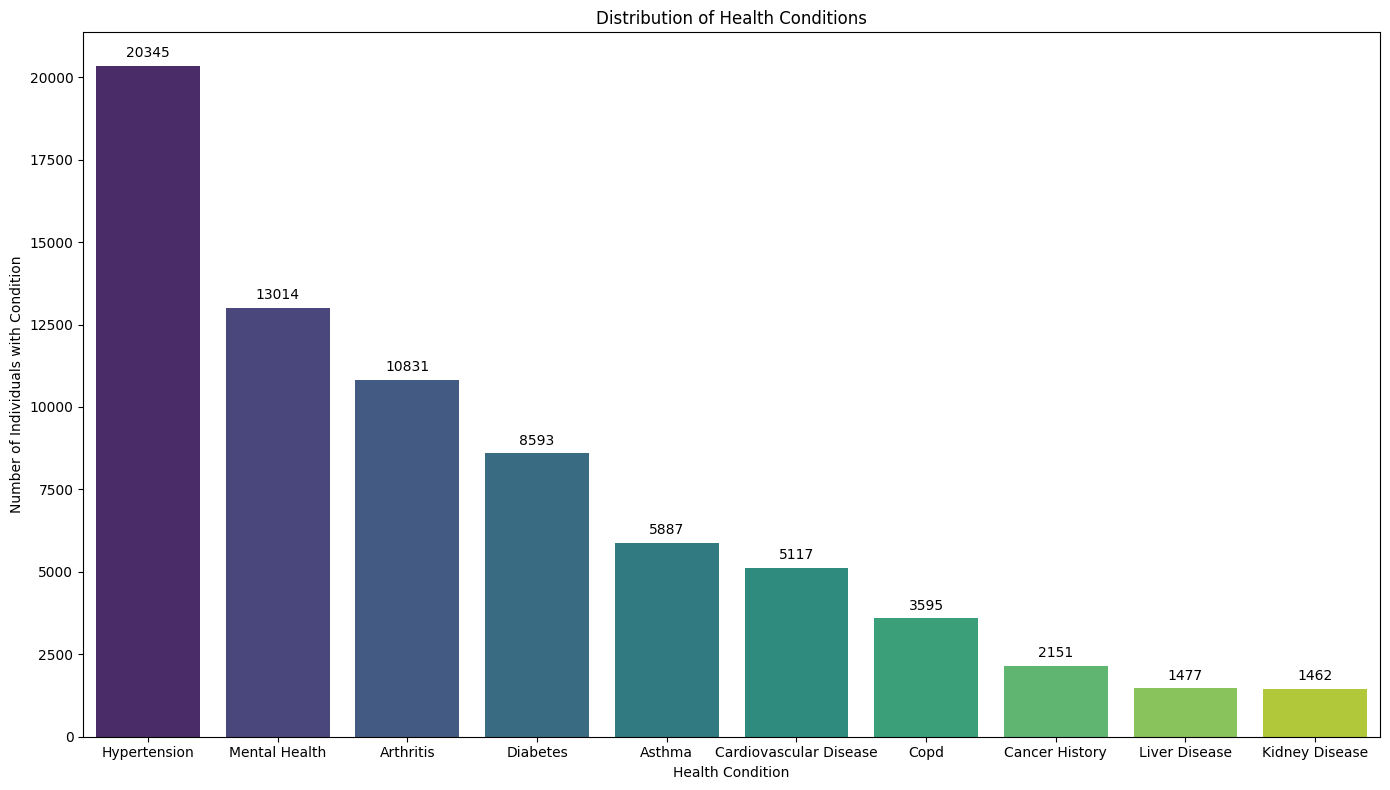

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the list of health condition columns
health_conditions = ['hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease',  'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health']

# Calculate the count of non-zero values (i.e., where the condition is present)
condition_counts = df_cleaned[health_conditions].sum().sort_values(ascending=False)

# Create a DataFrame for plotting
plot_df = pd.DataFrame({'Condition': condition_counts.index.str.replace('_', ' ').str.title(),
 'Count': condition_counts.values})

plt.figure(figsize=(14, 8))
ax = sns.barplot(x='Condition', y='Count', data=plot_df, palette='viridis', hue='Condition', legend=False)
plt.title('Distribution of Health Conditions')
plt.xlabel('Health Condition')
plt.ylabel('Number of Individuals with Condition')

# Wrap x-tick labels for better readability
for label in ax.get_xticklabels():
    label.set_wrap(True)
    label.set_horizontalalignment('center')

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

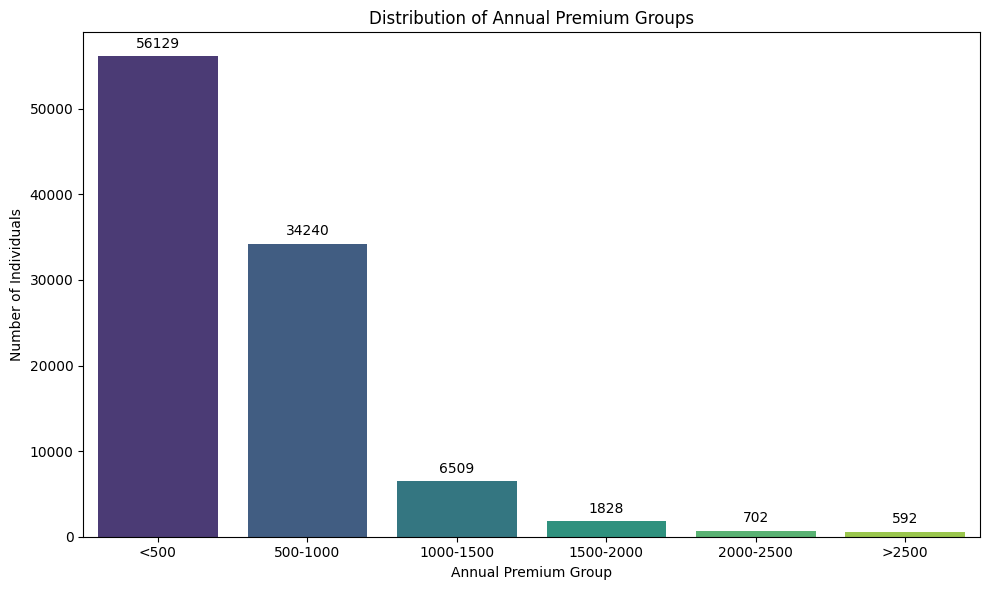

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define bin edges and labels for 'annual_premium'
premium_bins = [0, 500, 1000, 1500, 2000, 2500, np.inf]
premium_labels = ['<500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '>2500']
df_cleaned['annual_premium_group'] = pd.cut(df_cleaned['annual_premium'], bins=premium_bins, labels=premium_labels, right=False)

# Count the number of individuals in each annual premium group
premium_group_counts = df_cleaned['annual_premium_group'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=premium_group_counts.index, y=premium_group_counts.values, palette='viridis', hue=premium_group_counts.index, legend=False)
plt.title('Distribution of Annual Premium Groups')
plt.xlabel('Annual Premium Group')
plt.ylabel('Number of Individuals')

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

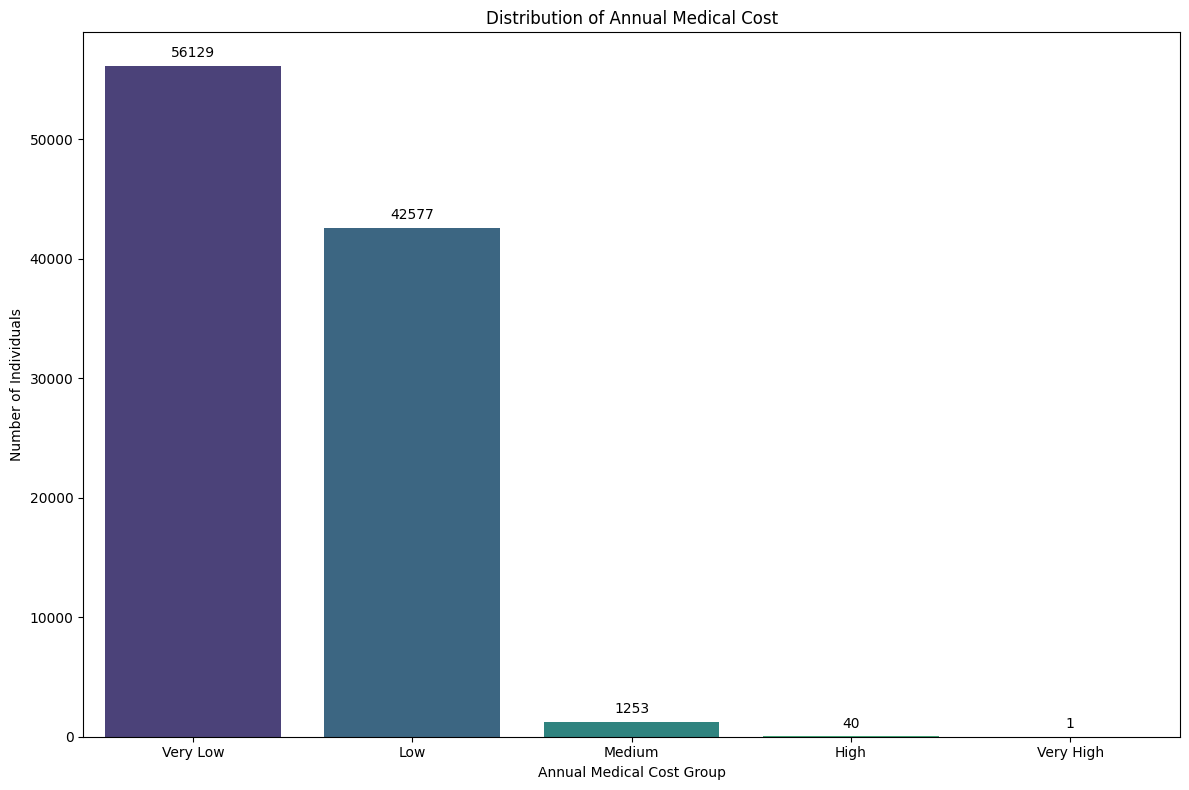

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each annual_medical_cost_grouped category
medical_cost_counts = df_cleaned['annual_medical_cost_grouped'].value_counts().reset_index()
medical_cost_counts.columns = ['Annual Medical Cost Group', 'Count']

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Annual Medical Cost Group', y='Count', data=medical_cost_counts, palette='viridis', hue='Annual Medical Cost Group', legend=False)
plt.title('Distribution of Annual Medical Cost')
plt.xlabel('Annual Medical Cost Group')
plt.ylabel('Number of Individuals')

# Wrap x-tick labels
for label in ax.get_xticklabels():
    label.set_wrap(True)
    label.set_horizontalalignment('center') # Center align wrapped text

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

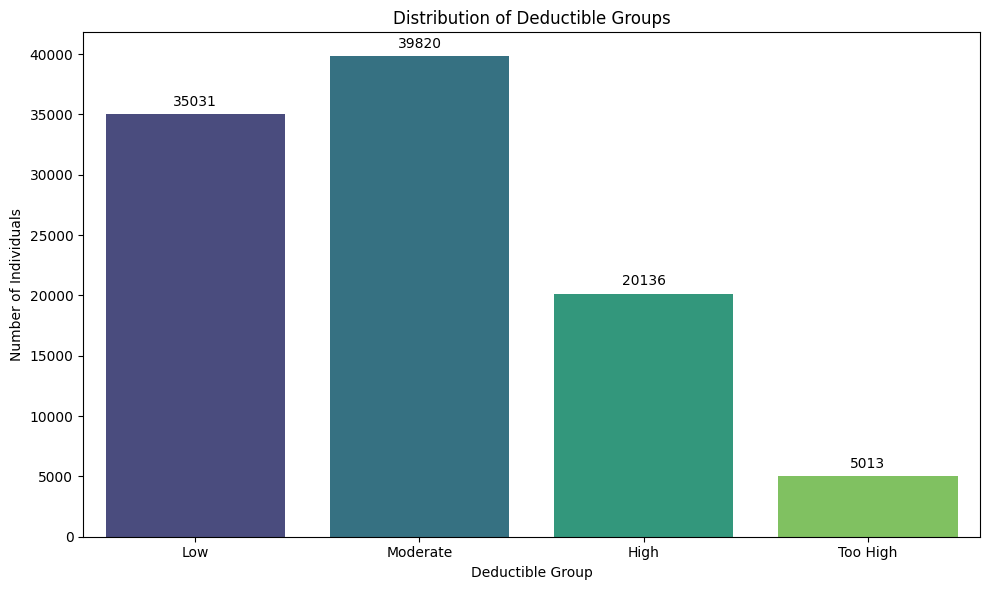

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define bin edges and labels for 'deductible'
deductible_bins = [0, 1000, 2000, 3000, np.inf]
deductible_labels = ['Low', 'Moderate', 'High', 'Too High']
df_cleaned['deductible_group'] = pd.cut(df_cleaned['deductible'], bins=deductible_bins, labels=deductible_labels, right=False)

# Count the number of individuals in each deductible group
deductible_group_counts = df_cleaned['deductible_group'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=deductible_group_counts.index, y=deductible_group_counts.values, palette='viridis', hue=deductible_group_counts.index, legend=False)
plt.title('Distribution of Deductible Groups')
plt.xlabel('Deductible Group')
plt.ylabel('Number of Individuals')

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

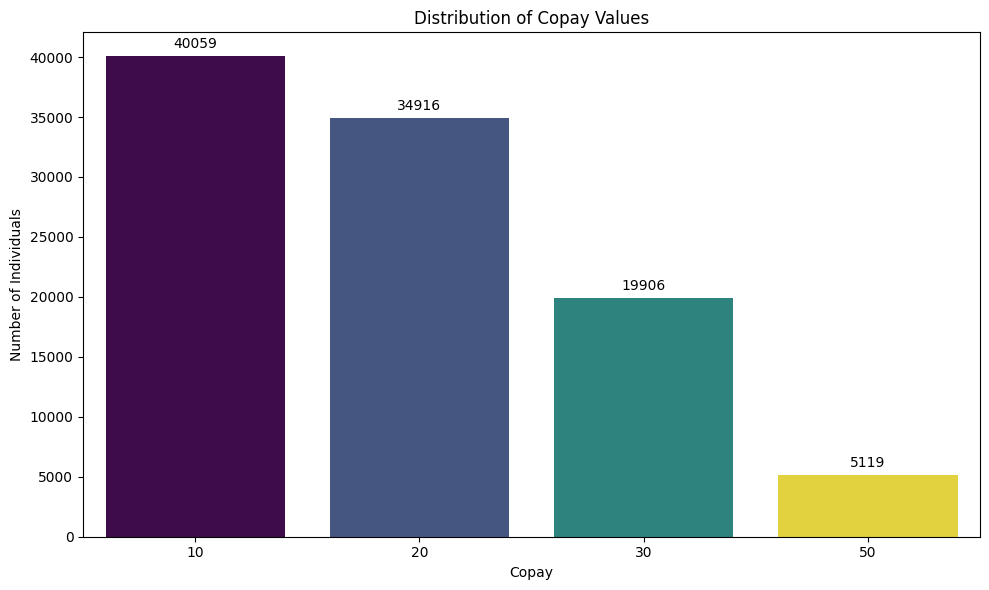

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each copay value
copay_counts = df_cleaned['copay'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=copay_counts.index, y=copay_counts.values, palette='viridis', hue=copay_counts.index, legend=False)
plt.title('Distribution of Copay Values')
plt.xlabel('Copay')
plt.ylabel('Number of Individuals')

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()